# 🌱 The Aluco Evidence Case
### From a field image to an honest scientific claim

**90-minute hands-on · no programming experience needed**

<div style="padding:12px;border-radius:10px;background:#eef7f2;text-align:center;font-size:17px">
🔎 FIELD &nbsp;→&nbsp; 🧩 DESIGN &nbsp;→&nbsp; 📊 MODEL &nbsp;→&nbsp; 🚦 CHECK &nbsp;→&nbsp; 🤖 CNN &nbsp;→&nbsp; ✍️ CLAIM
</div>

Today you are the scientist. The computer calculates; **you decide what the evidence means**.

## How to play

**🎯 Predict → ▶ Run → 👀 Observe → ✅ Decide**

Work in pairs: one **Agronomist** explains the field; one **Analyst** runs the cell and reads the graph. Swap roles after Mission 4.

Run the setup once. Its long code is hidden because this lesson is about scientific decisions, not Python syntax.

In [1]:
#@title 0. Run setup once { display-mode: "form" }
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.patches import FancyBboxPatch, Polygon
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

ORDER = ["Control", "Fungicide", "Inoculated"]
COLORS = {"Control": "#667085", "Fungicide": "#169B62", "Inoculated": "#E76F51"}
RAW = "https://raw.githubusercontent.com/Facuriy/agro-data-analysis-hands-on/v2.1.0"

root = next((p for p in [Path("."), Path("..")] if (p / "data").exists()), None)

def _table(name):
    return pd.read_csv(root / "data" / name if root else f"{RAW}/data/{name}")

def _picture(name):
    if root:
        return np.asarray(Image.open(root / "assets" / name).convert("RGB"))
    payload = urlopen(f"{RAW}/assets/{name}").read()
    return np.asarray(Image.open(BytesIO(payload)).convert("RGB"))

field = _table("field_plots.csv")
events = _table("field_events.csv")
cnn = _table("cnn_model_outputs.csv")
rgb_early = _picture("rgb_early_512.jpg")
rgb_late = _picture("rgb_late_512.jpg")
field["treatment"] = pd.Categorical(field["treatment"], ORDER, ordered=True)
field["block"] = pd.Categorical(field["block"])
events["date"] = pd.to_datetime(events["date"])

def _points(wkt_text):
    nums = [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?", wkt_text)]
    return np.asarray(list(zip(nums[0::2], nums[1::2])))

def _rgb(ax, image, title=""):
    ax.imshow(image, origin="upper", extent=(0, 512, 512, 0), interpolation="nearest")
    # Crop the white margins while preserving the real image and pixel coordinates.
    ax.set(xlim=(0, 512), ylim=(390, 120), xticks=[], yticks=[], title=title)
    ax.set_aspect("equal")

def _outline(ax, row, column, color="white", lw=1.2, label=False):
    value = getattr(row, column) if hasattr(row, column) else row[column]
    pts = _points(value)
    ax.add_patch(Polygon(pts, fill=False, edgecolor=color, linewidth=lw))
    if label:
        center = pts[:-1].mean(axis=0)
        ax.text(center[0], center[1], row.plot_id, ha="center", va="center",
                fontsize=7.5, weight="bold", color="black",
                bbox=dict(boxstyle="round,pad=.12", fc="white", ec="none", alpha=.82))

def _crop(image, wkt_text, pad=3):
    pts = _points(wkt_text)
    x0, y0 = np.floor(pts.min(axis=0) - pad).astype(int)
    x1, y1 = np.ceil(pts.max(axis=0) + pad).astype(int)
    x0, y0 = max(x0, 0), max(y0, 0)
    x1, y1 = min(x1, image.shape[1]), min(y1, image.shape[0])
    return image[y0:y1, x0:x1]

def mystery_images():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    _rgb(axes[0], rgb_early, "Image A")
    _rgb(axes[1], rgb_late, "Image B")
    fig.suptitle("FIELD DETECTIVE · Which image came later?", fontsize=17, weight="bold")
    plt.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def reveal_field():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    for ax, image, polygon, title in [
        (axes[0], rgb_early, "polygon_early_px", "26 June · 81 DAS"),
        (axes[1], rgb_late, "polygon_late_px", "3 September · 150 DAS"),
    ]:
        _rgb(ax, image, title)
        for row in field.itertuples():
            _outline(ax, row, polygon, label=True)
    fig.suptitle("REVEAL · Same 12 experimental plots, two dates", fontsize=17, weight="bold")
    plt.tight_layout(rect=(0, 0, 1, .92))
    plt.show()
    print("One plot received one treatment. Pixels and image crops are measurements—not experimental units.")

def plot_passports():
    selected = field[field.block.astype(int).eq(1)].copy().sort_values("treatment")
    fig, axes = plt.subplots(2, 3, figsize=(11, 5.2))
    for col, (_, row) in enumerate(selected.iterrows()):
        axes[0, col].imshow(_crop(rgb_early, row.polygon_early_px))
        axes[1, col].imshow(_crop(rgb_late, row.polygon_late_px))
        axes[0, col].set_title(f"{row.plot_id} · June")
        axes[1, col].set_title(
            f"September\n{row.treatment} · severity {row.severity_sep04} · sugar {row.sugar_content_pct:.1f}%",
            color=COLORS[str(row.treatment)], fontsize=10,
        )
        for ax in axes[:, col]:
            ax.axis("off")
    fig.suptitle("THREE PLOT PASSPORTS · one block, three treatments", fontsize=17, weight="bold")
    plt.tight_layout(rect=(0, 0, 1, .91))
    plt.show()

def evidence_maps():
    specs = [
        ("late_green_share", "Green share\ncontinuous", "YlGn", None),
        ("severity_sep04", "Disease severity\nordered score", "OrRd", None),
        ("sugar_content_pct", "Sugar content\ncontinuous outcome", "viridis", None),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.4))
    for ax, (column, title, cmap_name, _) in zip(axes, specs):
        _rgb(ax, rgb_late, title)
        ax.images[0].set_alpha(.18)
        patches = [Polygon(_points(text), closed=True) for text in field.polygon_late_px]
        values = field[column].to_numpy(float)
        collection = PatchCollection(
            patches, cmap=cmap_name, norm=Normalize(values.min(), values.max()),
            edgecolor="white", linewidth=1.3, alpha=.9,
        )
        collection.set_array(values)
        ax.add_collection(collection)
        for row in field.itertuples():
            pts = _points(row.polygon_late_px)
            center = pts[:-1].mean(axis=0)
            ax.text(*center, row.plot_id, ha="center", va="center", fontsize=7, weight="bold")
        fig.colorbar(collection, ax=ax, shrink=.67, pad=.02)
    fig.suptitle("EVIDENCE MAP · same field, three different variables", fontsize=17, weight="bold")
    plt.tight_layout(rect=(0, 0, 1, .91))
    plt.show()

def baseline_trap():
    chosen = ["E01", "E02", "E03", "E04", "E08", "E09", "E10"]
    timeline = events[events.event_id.isin(chosen)].copy()
    timeline["short"] = [
        "Sowing", "Inoculation /\ncanopy closure", "RGB 1", "Fungicide 1",
        "RGB 2", "Severity", "Harvest",
    ]
    palette = {
        "crop": "#667085", "crop_management": "#8C6D31", "image": "#2878B5",
        "fungicide": "#169B62", "disease": "#E76F51", "harvest": "#8C6D31",
    }
    label_x = {"E01": 0, "E02": 66, "E03": 82, "E04": 99, "E08": 145, "E09": 158, "E10": 200}
    label_y = {"E01": .36, "E02": -.42, "E03": .42, "E04": -.42, "E08": .36, "E09": -.36, "E10": .36}
    fig, ax = plt.subplots(figsize=(12, 3.6))
    ax.hlines(0, 0, 200, color=".65", lw=3)
    for _, row in timeline.iterrows():
        x_text, y_text = label_x[row.event_id], label_y[row.event_id]
        y_dot = .025 if row.event_id == "E03" else (-.025 if row.event_id == "E04" else 0)
        ax.scatter(row.days_after_sowing, y_dot, s=120, color=palette[row.event_type], zorder=3)
        ax.annotate(
            f"{row.short}\nDAS {row.days_after_sowing}",
            xy=(row.days_after_sowing, y_dot), xytext=(x_text, y_text),
            ha="center", va="bottom" if y_text > 0 else "top", fontsize=8.5,
            arrowprops=dict(arrowstyle="-", color=palette[row.event_type], lw=1.3),
        )
    ax.axvspan(80.3, 81.7, color="#FFD166", alpha=.35)
    ax.text(81, .62, "SAME DAY", ha="center", weight="bold", color="#9C6B00")
    ax.set(xlim=(-5, 205), ylim=(-.85, .85), xlabel="Days after sowing", yticks=[])
    sns.despine(ax=ax, left=True)
    ax.set_title("BASELINE TRAP · RGB 1 is not a clean pretreatment baseline", fontsize=17)
    plt.tight_layout()
    plt.show()

def method_map():
    fig, ax = plt.subplots(figsize=(10.5, 3.1))
    ax.axis("off")
    boxes = [
        (.02, .34, .18, .34, "Sugar\ncontinuous", "#DCEAF3"),
        (.27, .34, .18, .34, "Blocked\nexperiment", "#E8F5E9"),
        (.52, .34, .20, .34, "Treatment\n+ block", "#BFE7DF"),
        (.79, .52, .19, .28, "Primary\nanalysis", "#70C1B3"),
        (.79, .08, .19, .28, "ANCOVA\nsensitivity only", "#FFE0B2"),
    ]
    for x, y, w, h, label, color in boxes:
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=.02",
                                    fc=color, ec="white", lw=2, transform=ax.transAxes))
        ax.text(x+w/2, y+h/2, label, transform=ax.transAxes, ha="center", va="center", weight="bold")
    for start, end in [((.20, .51), (.27, .51)), ((.45, .51), (.52, .51)),
                       ((.72, .51), (.79, .66)), ((.72, .48), (.79, .22))]:
        ax.annotate("", xy=end, xytext=start, xycoords=ax.transAxes,
                    arrowprops=dict(arrowstyle="->", lw=2, color=".35"))
    ax.text(.755, .30, "June RGB?", transform=ax.transAxes, ha="center", fontsize=9, color="#9C6B00")
    ax.set_title("CHOOSE THE ANALYSIS · question + outcome + design + timing", fontsize=17)
    plt.show()

def _models():
    primary = smf.ols("sugar_content_pct ~ C(treatment) + C(block)", data=field).fit()
    centered = field.assign(green_c=field.early_green_share - field.early_green_share.mean())
    ancova = smf.ols("sugar_content_pct ~ C(treatment) + C(block) + green_c", data=centered).fit()
    return primary, ancova

def analyze_field():
    global model, contrasts
    model, ancova = _models()
    p_primary = anova_lm(model, typ=2).loc["C(treatment)", "PR(>F)"]
    p_ancova = anova_lm(ancova, typ=2).loc["C(treatment)", "PR(>F)"]

    terms = {
        "Fungicide − Control": "C(treatment)[T.Fungicide]",
        "Inoculated − Control": "C(treatment)[T.Inoculated]",
    }
    ci = model.conf_int()
    rows = []
    for label, term in terms.items():
        rows.append({
            "contrast": label,
            "difference": model.params[term],
            "low": ci.loc[term, 0],
            "high": ci.loc[term, 1],
            "p_raw": model.pvalues[term],
        })
    contrasts = pd.DataFrame(rows)
    contrasts["p_holm"] = multipletests(contrasts.p_raw, method="holm")[1]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.1, 1.1]})
    for _, row in field.iterrows():
        x = ORDER.index(str(row.treatment))
        axes[0].plot(x, row.sugar_content_pct, "o", ms=8, color=COLORS[str(row.treatment)], alpha=.85)
    means = field.groupby("treatment", observed=True).sugar_content_pct.mean().reindex(ORDER)
    axes[0].plot(range(3), means, "_", color="black", ms=24, mew=3)
    axes[0].set(xticks=range(3), xticklabels=ORDER, ylabel="Sugar content (%)", title="12 plots + means")
    axes[0].tick_params(axis="x", rotation=18)

    y = np.array([1, 0])
    axes[1].axvline(0, color=".4", ls="--")
    axes[1].errorbar(contrasts.difference, y,
                     xerr=[contrasts.difference-contrasts.low, contrasts.high-contrasts.difference],
                     fmt="o", color="#245B78", capsize=5, ms=8)
    for yi, row in zip(y, contrasts.itertuples()):
        axes[1].text(row.high + .06, yi, f"Holm p={row.p_holm:.3g}", va="center", fontsize=9)
    axes[1].set(yticks=y, yticklabels=contrasts.contrast,
                xlabel="Difference in sugar (percentage points)", title="Two planned comparisons")
    axes[1].set_xlim(-2.0, 1.35)

    block_order = field.block.astype(int).sort_values().unique()
    for treatment in ORDER:
        group = field[field.treatment.eq(treatment)].copy().sort_values("block")
        axes[2].plot(group.block.astype(int), group.sugar_content_pct, marker="o",
                     color=COLORS[treatment], label=treatment, lw=2)
    axes[2].set(xticks=block_order, xlabel="Field block", ylabel="Sugar content (%)",
                title="Pattern across blocks")
    axes[2].legend(frameon=False, fontsize=8)
    fig.suptitle("MODEL REVEAL · estimates before stars", fontsize=18, weight="bold")
    plt.tight_layout(rect=(0, 0, 1, .91))
    plt.show()

    print(f"Primary blocked model: treatment p = {p_primary:.3g}")
    print(f"ANCOVA sensitivity:   treatment p = {p_ancova:.3g}  ← same story, different conditional question")
    print("Balanced design note: block-adjusted and raw treatment means coincide here.")

def model_health():
    global model
    if "model" not in globals():
        model, _ = _models()
    influence = model.get_influence()
    cooks = influence.cooks_distance[0]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].scatter(model.fittedvalues, model.resid, color="#245B78", s=60)
    axes[0].axhline(0, color=".4", ls="--")
    axes[0].set(xlabel="Fitted", ylabel="Residual", title="1 · Pattern?")
    sm.qqplot(model.resid, line="45", fit=True, ax=axes[1])
    axes[1].set_title("2 · Strong outlier?")
    axes[2].stem(np.arange(1, len(field)+1), cooks, basefmt=" ")
    axes[2].axhline(4/len(field), color="#E76F51", ls="--", label="4/n guide")
    for i, value in enumerate(cooks):
        if value > 4/len(field):
            axes[2].text(i+1, value+.015, field.iloc[i].plot_id, ha="center", fontsize=8, weight="bold")
    axes[2].set(xlabel="Plot number", ylabel="Cook's distance", title="3 · Influential plot?")
    axes[2].legend(frameon=False, fontsize=8)
    fig.suptitle("MODEL HEALTH CHECK · inspect, do not delete automatically", fontsize=17, weight="bold")
    plt.tight_layout(rect=(0, 0, 1, .91))
    plt.show()
    print("Teaching verdict: 🟡 useful summary, but only 12 plots; report the caution.")

def residual_map():
    global model
    if "model" not in globals():
        model, _ = _models()
    residuals = pd.Series(np.asarray(model.resid), index=field.plot_id)
    values = field.plot_id.map(residuals).to_numpy()
    limit = max(abs(values.min()), abs(values.max()))
    fig, ax = plt.subplots(figsize=(7, 5.6))
    _rgb(ax, rgb_late, "PATTERN HUNT · residuals back on the field")
    ax.images[0].set_alpha(.22)
    patches = [Polygon(_points(text), closed=True) for text in field.polygon_late_px]
    collection = PatchCollection(patches, cmap="RdBu_r",
                                 norm=TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit),
                                 edgecolor="white", linewidth=1.4, alpha=.9)
    collection.set_array(values)
    ax.add_collection(collection)
    for row in field.itertuples():
        pts = _points(row.polygon_late_px)
        center = pts[:-1].mean(axis=0)
        ax.text(*center, row.plot_id, ha="center", va="center", fontsize=8, weight="bold")
    fig.colorbar(collection, ax=ax, shrink=.68, label="Observed − fitted sugar (percentage points)")
    plt.tight_layout()
    plt.show()
    print("Preview-pixel coordinates only: visual diagnostic, not a spatial model.")

def inspect_cnn(fold=1):
    fold = int(fold)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    for ax, image, polygon, title in [
        (axes[0], rgb_early, "polygon_early_px", "26 June"),
        (axes[1], rgb_late, "polygon_late_px", "3 September"),
    ]:
        _rgb(ax, image, title)
        for row in field.itertuples():
            selected = int(row.block) == fold
            _outline(ax, row, polygon, color="#E76F51" if selected else "white",
                     lw=3 if selected else .7, label=selected)
    fig.suptitle(f"LEAKAGE TRAP · Fold {fold}: TEST = all plots from Block {fold}", fontsize=17, weight="bold")
    plt.tight_layout(rect=(0, 0, 1, .91))
    plt.show()
    print("The same field block never appears in both train and test for this fold.")

def evaluate_cnn():
    cnn_local = cnn.copy()
    cnn_local["correct"] = cnn_local.true_class.eq(cnn_local.cnn_prediction)
    groups = list(cnn_local.groupby("date", sort=True))
    fig = plt.figure(figsize=(13, 5))
    grid = fig.add_gridspec(1, 3, width_ratios=[.8, 1, 1])
    ax0 = fig.add_subplot(grid[0, 0])
    counts = [int(g.correct.sum()) for _, g in groups]
    ax0.bar([0, 1], counts, color=["#7BAFD4", "#169B62"], width=.62)
    for x, value in enumerate(counts):
        ax0.text(x, value+.25, f"{value}/12", ha="center", weight="bold", fontsize=14)
    ax0.set(xticks=[0, 1], xticklabels=["26 June", "3 September"], ylim=(0, 12.8),
            ylabel="Correct plot predictions", title="Correct predictions")
    ax0.tick_params(axis="x", rotation=15)
    for ax, (date, group), title in zip(
        [fig.add_subplot(grid[0, 1]), fig.add_subplot(grid[0, 2])],
        groups, ["26 June", "3 September"],
    ):
        ConfusionMatrixDisplay.from_predictions(
            group.true_class, group.cnn_prediction, labels=ORDER,
            display_labels=["Ctrl", "Fung.", "Inoc."], cmap="Blues", colorbar=False, ax=ax,
        )
        ax.set_title(f"Errors · {title}")
        ax.set_xlabel("CNN prediction")
    fig.suptitle("CNN EVIDENCE · 24 image rows, but only 12 field units", fontsize=17, weight="bold")
    plt.tight_layout(rect=(0, 0, 1, .91))
    plt.show()
    print("Descriptive only: 4/12 vs 7/12 does not prove a general date effect or deployment readiness.")

print("✅ Ready: 12 real plots · 2 real RGB dates · 7 short missions")

✅ Ready: 12 real plots · 2 real RGB dates · 7 short missions


## Mission 1 · Field detective ⏱ 8 min

**Question:** Which image came later—A or B? Point to one visible clue.

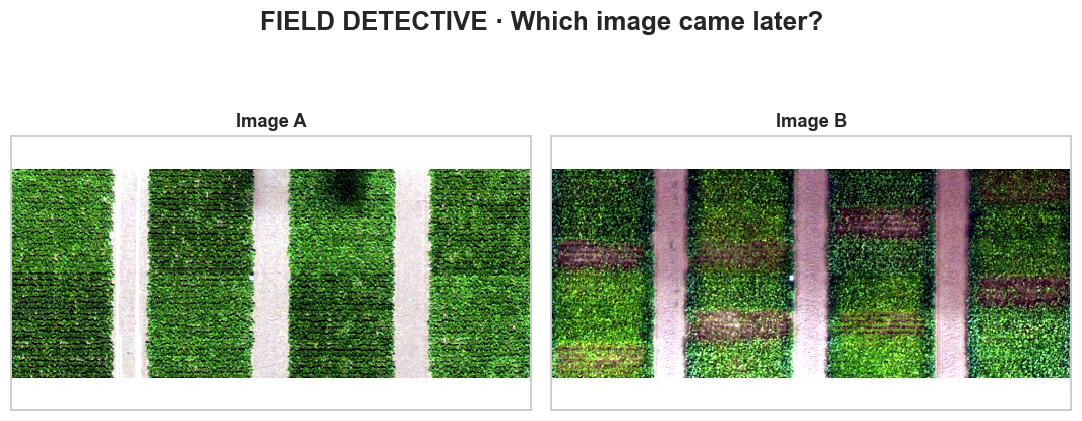

In [2]:
mystery_images()

Vote: **A · B · unsure**. Then reveal the dates and experimental plots.

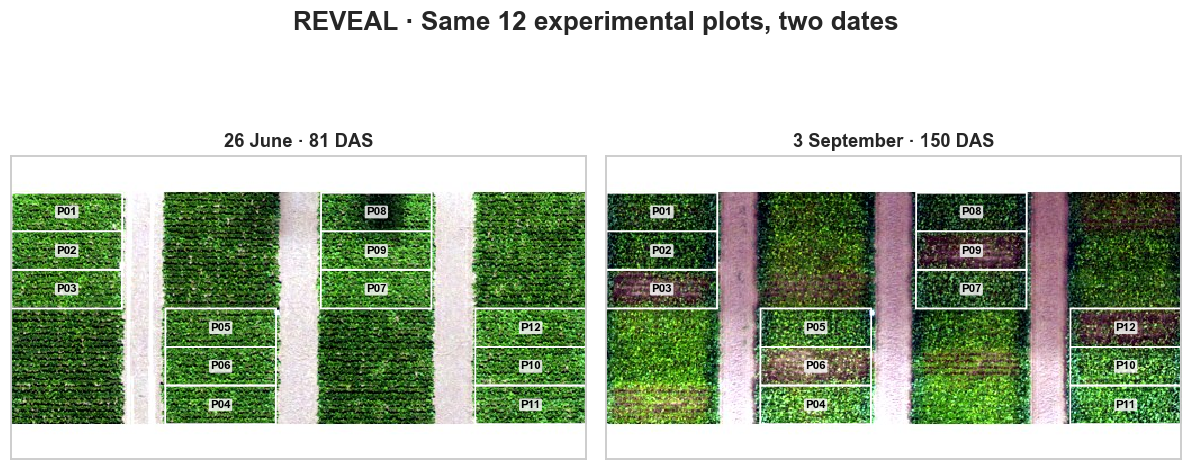

One plot received one treatment. Pixels and image crops are measurements—not experimental units.


In [3]:
reveal_field()

**Decide:** What is the experimental unit: a pixel, an image crop, or a field plot?

<details><summary>Check your answer</summary>
The <b>field plot</b>. It received the treatment. Pixels and crops are repeated measurements from that plot.
</details>

## Mission 2 · Read the field ⏱ 12 min

First guess which Block 1 plot is **Control**, **Fungicide**, or **Inoculated**. Then run the reveal.

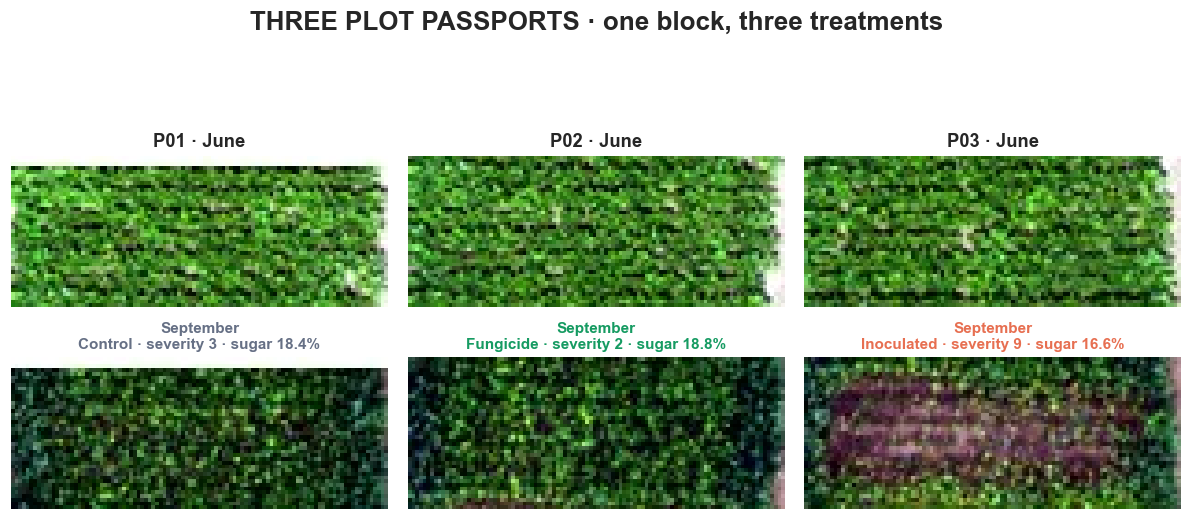

In [4]:
plot_passports()

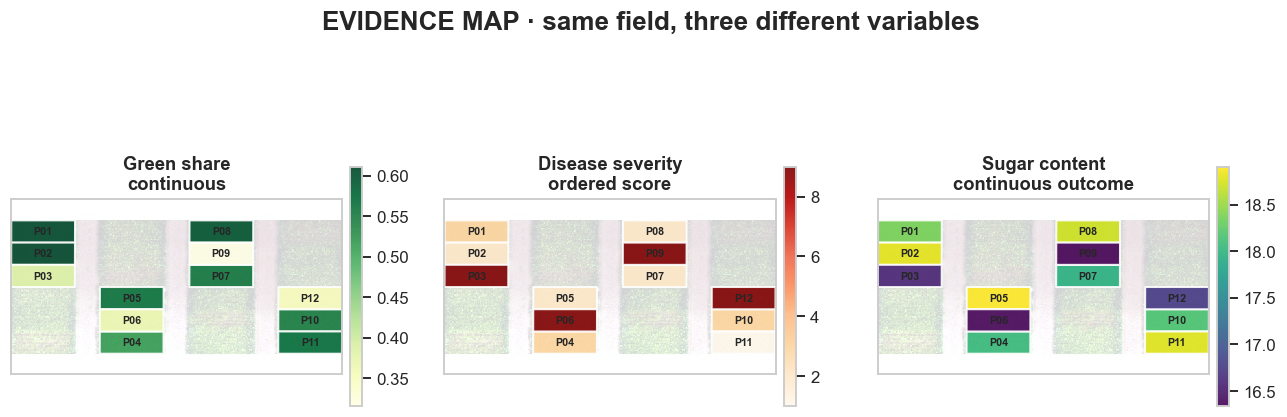

In [5]:
evidence_maps()

**Match each variable to its role:**

| Variable | Type | Today |
|---|---|---|
| Green share | continuous image descriptor | possible covariate |
| Disease severity | ordered score | supporting evidence |
| Sugar content | continuous laboratory value | **main outcome** |

A beautiful map is still not a statistical comparison.

## Mission 3 · The baseline trap ⏱ 8 min

**Predict:** Was June green share measured safely before treatment began?

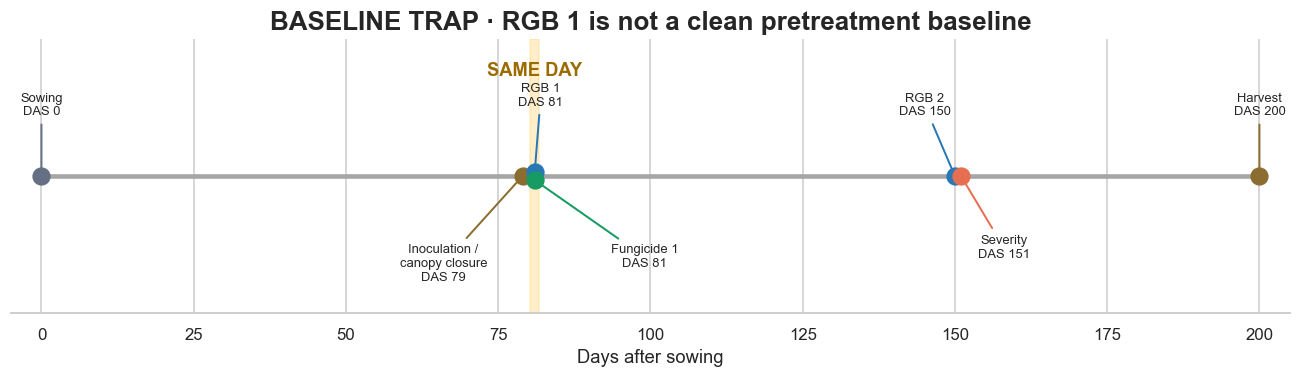

In [6]:
baseline_trap()

**Decision:** No. RGB 1 was after inoculation timing and on the same day as Fungicide 1; within-day order is unknown. Use it only as a **sensitivity analysis**, not as a clean baseline.

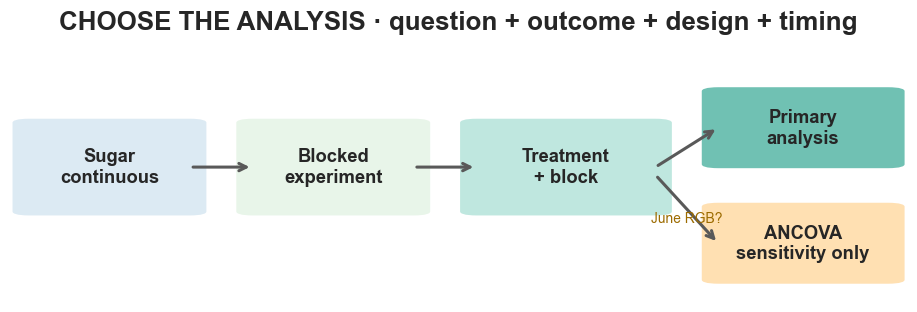

In [7]:
method_map()

## Mission 4 · Let the design choose the model ⏱ 16 min

Our main question is simple:

> Within Aluco, does sugar content differ among treatments after accounting for field block?

**Primary model:** `sugar ~ treatment + block`

Before running: predict the direction of both comparisons against Control.

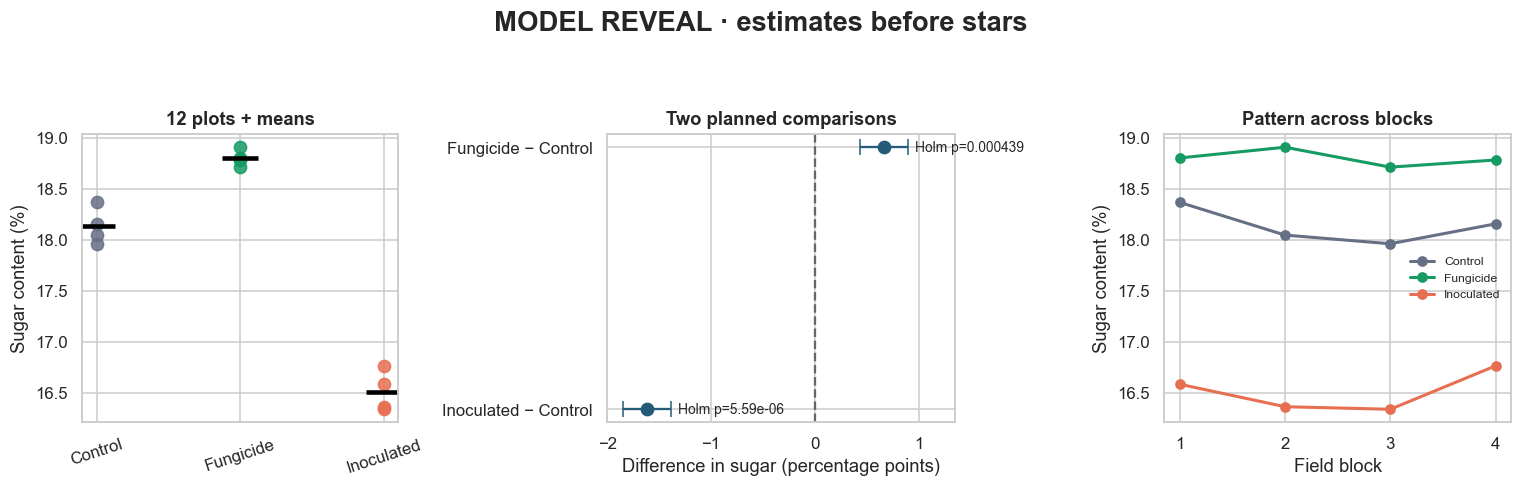

Primary blocked model: treatment p = 9.75e-07
ANCOVA sensitivity:   treatment p = 8.79e-06  ← same story, different conditional question
Balanced design note: block-adjusted and raw treatment means coincide here.


In [8]:
analyze_field()

**Read the forest plot:** dot = estimated difference; line = 95% CI; vertical line = no difference.

**Decide:** Which statement is supported?

- A. Fungicide is higher than Control and Inoculated is lower.
- B. Every fungicide always increases sugar yield.
- C. The cultivar caused the differences.

<details><summary>Answer</summary><b>A</b>. B generalizes beyond this experiment; C confuses cultivar selection with treatment comparison.</details>

## Mission 5 · Can we trust the summary? ⏱ 13 min

Use a traffic light: **🟢 no obvious problem · 🟡 caution · 🔴 stop and rethink**.

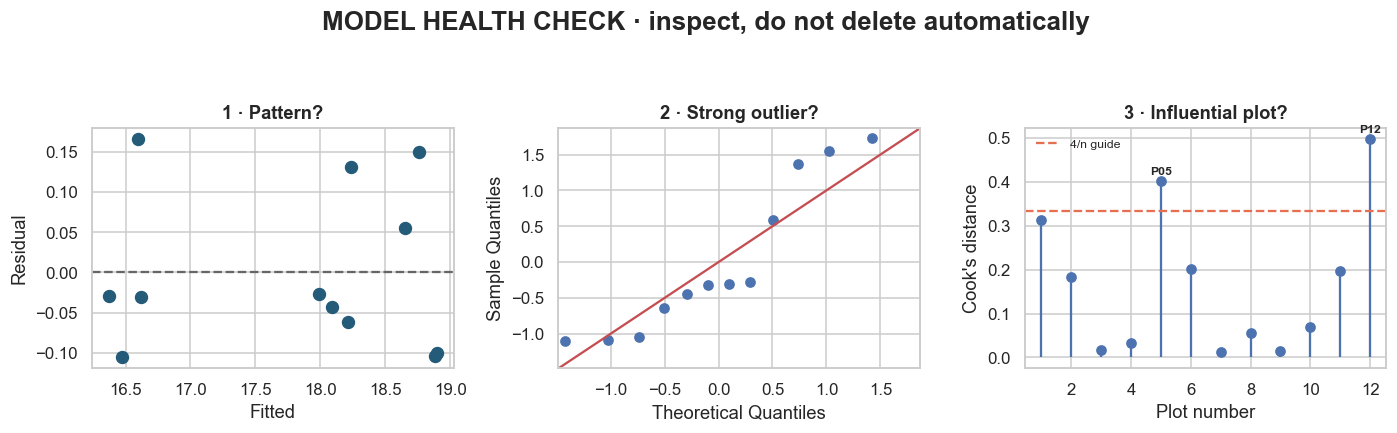

Teaching verdict: 🟡 useful summary, but only 12 plots; report the caution.


In [9]:
model_health()

Do not remove P05 or P12 automatically. An influential observation is a question to investigate—not permission to erase data.

**Pattern hunt:** gradient, local cluster, or no clear spatial pattern?

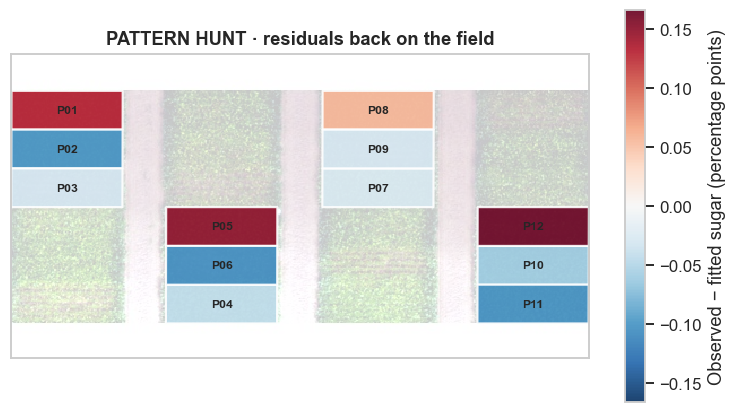

Preview-pixel coordinates only: visual diagnostic, not a spatial model.


In [10]:
residual_map()

## Mission 6 · The CNN leakage trap ⏱ 15 min

The same 12 plots were imaged twice. A random image split can put related field material in both training and test data.

Choose a block from **1 to 4**, edit the number, and run.

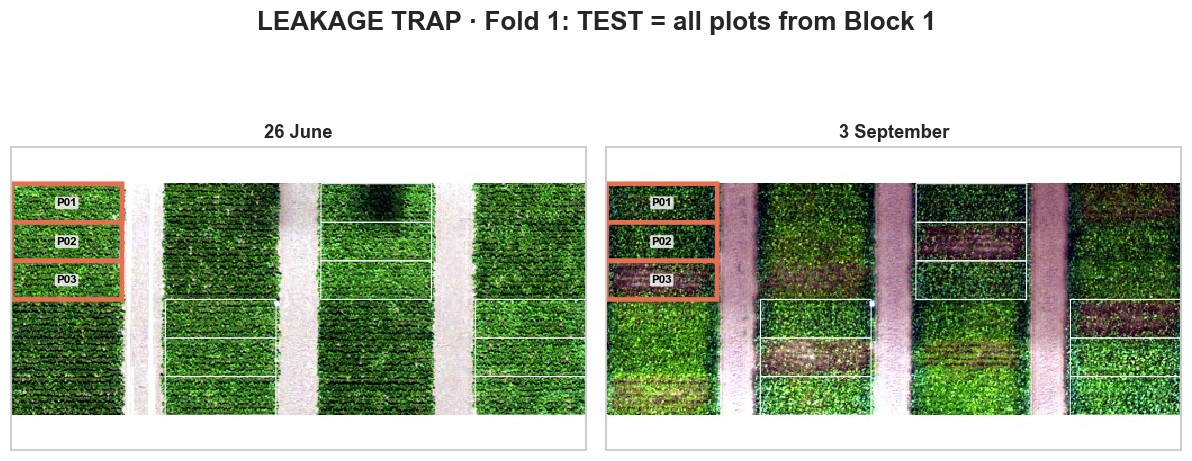

The same field block never appears in both train and test for this fold.


In [11]:
inspect_cnn(fold=1)  # change 1 to 2, 3, or 4

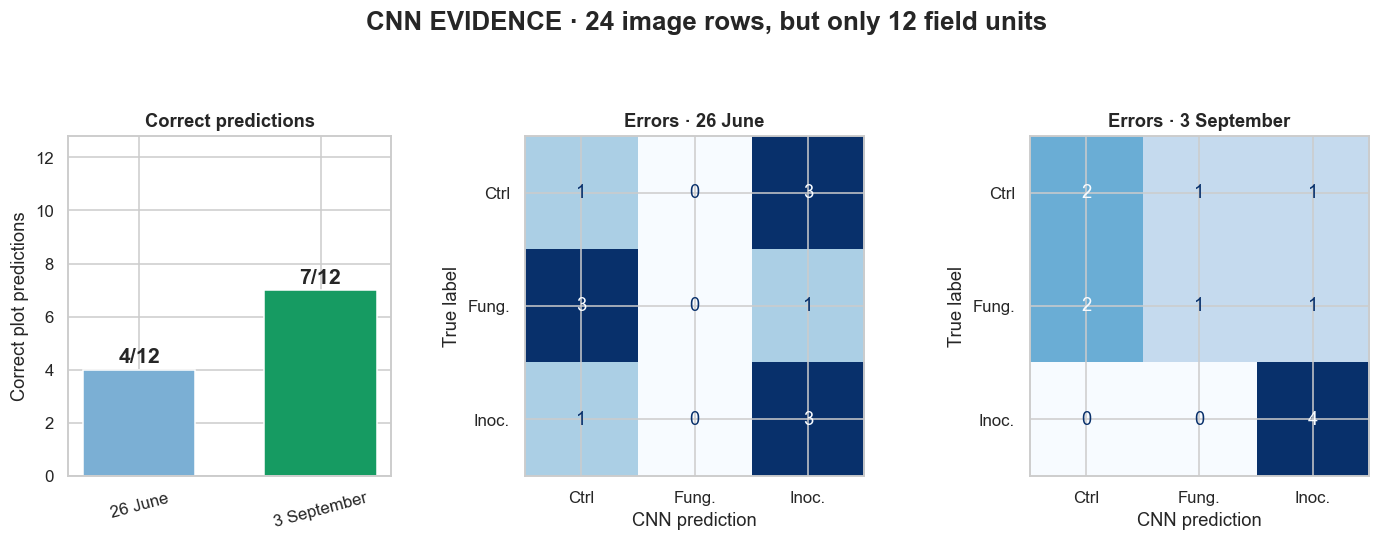

Descriptive only: 4/12 vs 7/12 does not prove a general date effect or deployment readiness.


In [12]:
evaluate_cnn()

**Deployment vote:** deploy now · test more · reject forever?

<details><summary>Check your answer</summary>
<b>Test more.</b> Grouped evaluation is better than a random image split, but four held-out blocks from one small experiment are not independent deployment validation. The two dates give 24 rows, not 24 experiments.
</details>

## Mission 7 · Write like a scientist ⏱ 12 min

Sort each card: **RESULT · DISCUSSION · NOT SUPPORTED**

| # | Card |
|---:|---|
| 1 | Inoculated plots had lower estimated sugar content than Control. |
| 2 | The difference proves that the pathogen directly reduced sugar. |
| 3 | The CNN classified 4/12 June and 7/12 September plot-images correctly. |
| 4 | Twelve plots from one cultivar limit generalization. |
| 5 | September is always the best date for CNN prediction. |
| 6 | An independent year and field should be tested next. |

<details><summary>Reveal</summary>
<b>RESULT:</b> 1, 3 · <b>DISCUSSION:</b> 4, 6 · <b>NOT SUPPORTED:</b> 2, 5
</details>

### Your two-sentence finish

**Result:** “In this Aluco subset, ______ differed from Control by ______ percentage points (95% CI ______ to ______).”

**Discussion:** “This may indicate ______, but ______ limits the claim; the next test should ______.”

---

## Exit ticket

1. What changed your mind today?
2. What can this experiment **not** claim?

**Take-home:** field → design → model → check → claim. A p-value never replaces that chain.

<details><summary>Five-word glossary</summary>
<b>Plot:</b> unit receiving treatment · <b>Block:</b> nearby plots grouped by design · <b>Outcome:</b> response being explained · <b>Residual:</b> observed minus fitted · <b>CI:</b> model-based uncertainty range
</details>